# Inspect the extracted tables

I checked the number of rows, missing values, and locations of the tables and it all seemed correct.

In [40]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(400)

polars.config.Config

In [41]:
# Path to parquet file
parquet_file = Path('/Volumes/TOSHIBA EXT/non-equilibrium/data/tables/2001.parquet')


# Load one year
df = pl.read_parquet(parquet_file)

In [42]:
# --------------------------------------------------
# Basic information
# --------------------------------------------------

print("=" * 60)
print("Dataset overview")
print("=" * 60)

print(f"Rows: {df.height:,}")
print(f"Columns: {df.width}")

print("\nColumns:")
print(df.columns)


# --------------------------------------------------
# Data types
# --------------------------------------------------

print("\nData types:")
print(df.schema)


# --------------------------------------------------
# First rows
# --------------------------------------------------

print("\nFirst rows:")
print(df.head())


# --------------------------------------------------
# Missing values
# --------------------------------------------------

print("\nMissing values:")
print(
    df.null_count()
)


# --------------------------------------------------
# Summary statistics
# --------------------------------------------------

print("\nSummary:")
print(
    df.describe()
)

Dataset overview
Rows: 2,913,692
Columns: 26

Columns:
['tmmn_mean', 'tmmx_mean', 'tmmn_min', 'tmmn_max', 'tmmx_min', 'tmmx_max', 'pr_sum', 'veg_tmmn_mean', 'veg_tmmx_mean', 'veg_tmmn_min', 'veg_tmmn_max', 'veg_tmmx_min', 'veg_tmmx_max', 'veg_pr_sum', 'vegetation_length', 'Gpp', 'Npp', 'Npp_QC', 'elevation_mean', 'longitude', 'latitude', 'year', 'iso3', 'name', 'continent', 'region']

Data types:
Schema({'tmmn_mean': Float32, 'tmmx_mean': Float32, 'tmmn_min': Float32, 'tmmn_max': Float32, 'tmmx_min': Float32, 'tmmx_max': Float32, 'pr_sum': Float32, 'veg_tmmn_mean': Float32, 'veg_tmmx_mean': Float32, 'veg_tmmn_min': Float32, 'veg_tmmn_max': Float32, 'veg_tmmx_min': Float32, 'veg_tmmx_max': Float32, 'veg_pr_sum': Float32, 'vegetation_length': Float32, 'Gpp': Float64, 'Npp': Float64, 'Npp_QC': Float64, 'elevation_mean': Float32, 'longitude': Float64, 'latitude': Float64, 'year': Int64, 'iso3': String, 'name': String, 'continent': String, 'region': String})

First rows:
shape: (5, 26)
┌───

In [43]:
print("\nLongitude range:")
print(
    df.select(
        pl.col("longitude").alias("min_lon").min(),
        pl.col("longitude").alias("max_lon").max()
    )
)

print("\nLatitude range:")
print(
    df.select(
        pl.col("latitude").alias("min_lat").min(),
        pl.col("latitude").alias("max_lat").max()
    )
)


Longitude range:
shape: (1, 2)
┌─────────────┬────────────┐
│ min_lon     ┆ max_lon    │
│ ---         ┆ ---        │
│ f64         ┆ f64        │
╞═════════════╪════════════╡
│ -179.999494 ┆ 179.999494 │
└─────────────┴────────────┘

Latitude range:
shape: (1, 2)
┌────────────┬───────────┐
│ min_lat    ┆ max_lat   │
│ ---        ┆ ---       │
│ f64        ┆ f64       │
╞════════════╪═══════════╡
│ -55.825326 ┆ 83.029774 │
└────────────┴───────────┘


In [44]:
print("\nNumber of regions:")
print(
    df.select(
        pl.col("region").n_unique()
    )
)

print("\nTop regions:")
print(
    df.group_by("region")
      .len()
      .sort("len", descending=True)
      .head(20)
)


Number of regions:
shape: (1, 1)
┌────────┐
│ region │
│ ---    │
│ u32    │
╞════════╡
│ 23     │
└────────┘

Top regions:
shape: (20, 2)
┌───────────────────────────┬────────┐
│ region                    ┆ len    │
│ ---                       ┆ ---    │
│ str                       ┆ u32    │
╞═══════════════════════════╪════════╡
│ Northern America          ┆ 501533 │
│ Eastern Europe            ┆ 453346 │
│ South America             ┆ 367846 │
│ Australia and New Zealand ┆ 275390 │
│ Eastern Asia              ┆ 232199 │
│ …                         ┆ …      │
│ Western Asia              ┆ 35732  │
│ Southern Europe           ┆ 28917  │
│ Western Europe            ┆ 16831  │
│ null                      ┆ 11374  │
│ Caribbean                 ┆ 5443   │
└───────────────────────────┴────────┘


In [45]:
print(
    df.select(
        [
            "Npp",
            "elevation_mean",
            "tmmn_mean",
            "pr_sum"
        ]
    ).describe()
)

shape: (9, 5)
┌────────────┬──────────────┬────────────────┬────────────┬────────────┐
│ statistic  ┆ Npp          ┆ elevation_mean ┆ tmmn_mean  ┆ pr_sum     │
│ ---        ┆ ---          ┆ ---            ┆ ---        ┆ ---        │
│ str        ┆ f64          ┆ f64            ┆ f64        ┆ f64        │
╞════════════╪══════════════╪════════════════╪════════════╪════════════╡
│ count      ┆ 2.913692e6   ┆ 2.910587e6     ┆ 2.910578e6 ┆ 2.910578e6 │
│ null_count ┆ 0.0          ┆ 3105.0         ┆ 3114.0     ┆ 3114.0     │
│ mean       ┆ 3835.2089    ┆ 717.656494     ┆ 6.013656   ┆ 726.366821 │
│ std        ┆ 3324.074282  ┆ 863.700073     ┆ 12.616148  ┆ 591.289246 │
│ min        ┆ 0.0          ┆ -354.0         ┆ -23.654795 ┆ 0.0        │
│ 25%        ┆ 1373.992976  ┆ 182.0          ┆ -5.336987  ┆ 303.0      │
│ 50%        ┆ 2723.868391  ┆ 416.0          ┆ 9.354247   ┆ 532.0      │
│ 75%        ┆ 5553.866437  ┆ 967.0          ┆ 17.280001  ┆ 992.0      │
│ max        ┆ 24315.694535 ┆ 5811.0 

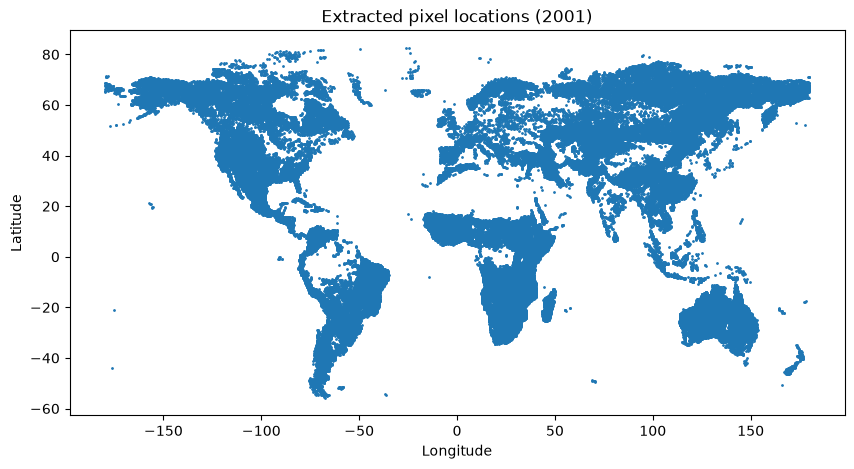

In [46]:
sample = df.sample(
    min(100000, df.height)
)


plt.figure(figsize=(10, 5))

plt.scatter(
    sample["longitude"],
    sample["latitude"],
    s=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Extracted pixel locations (2001)")

plt.show()